In [1]:
from random import seed
from random import random
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import numpy as np
from scipy.optimize import curve_fit
def fit_func(x, a, b):
    return a*x + b

In [2]:
def pressuredegrowth_3d(gnot=1,knot=0,pnott=10,ksii=0.01,ca=1,dep=1,\
                        uinput=0,turn=5,boxsize=200,finestep=1,timeused=10):
    #pressure dependent growth
    #parameter
    g=gnot #growth rate
    k=knot #sporulation rate
    ksi=ksii #friction coefficient
    pnot=pnott #pressure threshold for growth
    cap=ca #maximum cell/spore density at each site
    dt=0.001
    
    u=uinput #used to plot continuous graph for different gamma
    lengthscale=boxsize #proposed length of growing space
    
    finner=finestep
    finarea=finestep*finestep*finestep
    finint=int(finestep)
    #print(finner,finarea)
    
    print("pressure coefficient=",ksi)
    
    #checkpoint for looping
    checkpoint=timeused #could be time
    updateturn=turn
    #varying properties
    phi=np.zeros(lengthscale) #cell amount
    spore=np.zeros(lengthscale) #spore amount
    pressure=np.zeros(lengthscale) #pressure at each location
    speed=np.zeros(lengthscale)
    space=np.linspace(0,lengthscale,lengthscale)
    
    i=0
    areaapprox=np.zeros(lengthscale)
    while i<lengthscale:
        areaapprox[i]=(3*i*i+3*i+1)/(3*finarea)
        i=i+1
        
    #radius
    rovertime=[]
    rsimu=[]
    rsimutip=[]
    rsporesimutip=[]
    ranas=[]
    sumrecorded=[] #total amount of cell,
                    #may be used to compute radius
    #time
    timerecorded=[]
    timenow=0
    
    #cellpercent
    cellpercentrecorded=[]
    
    #initial condition
    i=0
    restofcell=1*finner*finner*finner
    while i<finner:
        if i<np.floor(finner*((1/ca)**(1/3))):
            phi[i]=ca
            restofcell=restofcell-ca*(3*i*i+3*i+1)
        else:
            phi[i]=restofcell/(3*i*i+3*i+1)
            restofcell=0
        spore[i]=0
        i=i+1
        
    R=finner*(3*(sum(phi*areaapprox)+sum(spore*areaapprox))/cap)**(1/3)
    edge=np.floor(R)
    
    loc=int(edge)
    effgrowth=g*(1-pressure/(pnot+dep*pressure))#*(np.array(pressure)<pnot)
    effsporulation=k+(phi)*0
    sumv=(speed[loc]+effgrowth[loc]*phi[loc]*(1/finner)/cap)
    
    while updateturn>0:
            #print(phi)
        effgrowth=g*(1-pressure/(pnot+dep*pressure))#*(np.array(pressure)<pnot)
        effsporulation=k+(phi)*0

        #speednew=np.copy(speed)
        rv=np.zeros(lengthscale)
        speednew=np.copy(speed)
        i=1
        while i<=edge:
            rv[i]=(rv[i-1]+phi[i-1]*effgrowth[i-1]\
                         *((3*i*i-3*i+1)/(3*finarea))/cap)
            speednew[i]=rv[i]/((i/finner)**2)
            i=i+1
        speed=speednew
        pressurenew=np.copy(pressure)

        effgrowth=g*(1-pressure/(pnot+dep*pressure))#*(np.array(pressure)<pnot)
        effsporulation=k+(phi)*0
        i=int(edge)+1
        while i>0:
            if i==int(edge)+1:
                pressurenew[i-1]=pressurenew[i] + ksi*sumv*(1/finner)
            else:
                pressurenew[i-1]=pressurenew[i] + ksi*speed[i]*(1/finner)
            i=i-1
        pressure=pressurenew
        updateturn=updateturn-1
    updateturn=turn
    #print(phi)
    effgrowth=g*(1-pressure/(pnot+dep*pressure))#*(np.array(pressure)<pnot)
    effsporulation=k+(phi)*0
    lowerbar=-1
    
    
    sumv=(rv[loc]+effgrowth[loc]*phi[loc]*((3*loc*loc+3*loc+1)/(3*finarea))/cap)/((R/finner)**2)
    
    #looping
    while checkpoint>0:
        original=np.copy(phi)
        fluxphi=np.zeros(lengthscale)
        fluxspore=np.zeros(lengthscale)
    
        rovertime.append(R)
        rsimu.append(np.argmax(phi))
        
        loc=int(edge)
        cellpercent=(sum(phi*areaapprox))\
                    /(sum(phi*areaapprox)+sum(spore*areaapprox))
        sumv=(rv[loc]+effgrowth[loc]*phi[loc]*((3*loc*loc+3*loc+1)/(3*finarea))/cap)/((R/finner)**2)
        
        #print("sumv=",sumv)
        
        i=len(phi)-1
        while i>0:
            if phi[i]+spore[i]<=0:
                i=i-1
            else:
                break
        rsimutip.append(i/finner)
        i=len(spore)-1
        while i>0:
            if spore[i]<cap*0.5:
                i=i-1
            else:
                break
        rsporesimutip.append(i/finner)
        timerecorded.append(timenow)
        cellpercentrecorded.append(cellpercent)
        sumrecorded.append(sum(phi*areaapprox)+sum(spore*areaapprox))

        #finding gradient/flux
        i=0
        while i<len(phi):
            if i==0:
                fluxphi[i]=phi[i]*rv[i+1]/((3*i*i+3*i+1)/(3*finarea))#(1/finner)
                fluxspore[i]=spore[i]*rv[i+1]/((3*i*i+3*i+1)/(3*finarea))
                #gradientv[i]=(v[i+1]-v[i])/1
            elif i==len(phi)-1:
                fluxphi[i]=(phi[i]*rv[i]-phi[i-1]*rv[i])/((3*i*i+3*i+1)/(3*finarea))
                fluxspore[i]=(spore[i]*rv[i]-spore[i-1]*rv[i])/((3*i*i+3*i+1)/(3*finarea))
            else:
                fluxphi[i]=(phi[i]*rv[i+1]-phi[i-1]*rv[i])/((3*i*i+3*i+1)/(3*finarea))
                fluxspore[i]=(spore[i]*rv[i+1]-spore[i-1]*rv[i])/((3*i*i+3*i+1)/(3*finarea))
            i=i+1
        phinew=phi+dt*(phi*effgrowth-effsporulation*phi-fluxphi)
        sporenew=spore+dt*(effsporulation*phi-fluxspore)
        Rnew=R+sumv*dt*finner
        R=Rnew
        
        timenow=timenow+dt

        phi=phinew
        spore=sporenew
        edge=np.floor(R)

        pressurenew=np.copy(pressure)
        speednew=np.copy(speed)
        if edge<lengthscale:
            recordlowerbar=1
            speednew=np.copy(speed)
            i=1
            while i<=edge:
                rv[i]=(rv[i-1]+phi[i-1]*effgrowth[i-1]\
                         *((3*i*i-3*i+1)/(3*finarea))/cap)
                speednew[i]=rv[i]/((i/finner)**2)
                i=i+1
            speed=speednew
            
            pressurenew=np.copy(pressure)

            i=int(np.ceil(R))
            lowerbar=-1
            #if i==2:
                #print(i,sumv,phi[i-1])
            while i>0:
                if i==int(np.ceil(R)):
                    pressurenew[i-1]=pressurenew[i] + ksi*sumv*(phi[i-1]/cap)*(1/finner)
                elif i>lowerbar:
                    pressurenew[i-1]=pressurenew[i] + ksi*speed[i]*(1/finner)
            
                i=i-1
            pressure=pressurenew
            
            effgrowth=g*(1-pressure/(pnot+dep*pressure))#*(np.array(pressure)<pnot)
            effsporulation=k+(phi)*0
            
            
            
        else:
            checkpoint=0
        checkpoint=checkpoint-dt
        if phi[len(phi)-7*finner]+spore[len(spore)-7*finner]>0:
            checkpoint=0

    
    #calculation for speed
    i=0
    speedovertime=[]
    speedott=[]
    tovert=[]
    
    #while i+1<len(rsimu):
    #    speedovertime.append((rsimu[i+1]-rsimu[i])/(timerecorded[i+1]-timerecorded[i]))
    #    tovert.append(timerecorded[i])
    #    i=i+1
    #i=0
    #while i+1<len(rsimutip):
    #    speedott.append((rsimutip[i+1]-rsimutip[i])/(timerecorded[i+1]-timerecorded[i]))
    #    i=i+1
    #speedrecorded
    #plt.figure(u)
    #plt.plot(timerecorded,rovertime,"b-",label="estimated")
    #plt.plot(timerecorded,rsimutip,"m-")
    #plt.plot(timerecorded,sumrecorded,"b-",label="amount of biomass")
    #plt.plot(timerecorded,rovertime,"b-",label="estimated")
    #plt.legend()
    #plt.xlabel("time",fontsize=18)
    #plt.ylabel("radius--length of biofilm",fontsize=18)
    #plt.legend(fontsize=18)
    #plt.show()
    #plt.figure(u+2)
    #print(max(pressure),max(speed))
    #print("pressure=",pressure)
    #print("speed=",speed)
    #plt.plot(space,phi,"r-",label="cell percent")
    #plt.plot(space,spore,"g-",label="spore percent")
    #plt.plot(space,pressure/max(pressure),"c-",label="pressure")
    
    #plt.plot(space,speed/max(speed),'m-',label="speed")
    #plt.plot(space,effgrowth/max(effgrowth),'p--',label='effgrowth')
    #print(effgrowth[0:10])
    #plt.plot(space,speed,"y-",label="velocity")
    #plt.ylabel("percent",fontsize=18)
    #plt.xlabel("radius",fontsize=18)
    #plt.legend(fontsize=18)
    #plt.show()
    
    return phi,spore,pressure,space,timerecorded,sumrecorded,rsimu,rsimutip,speedovertime,speedott

pressure coefficient= 0.01


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


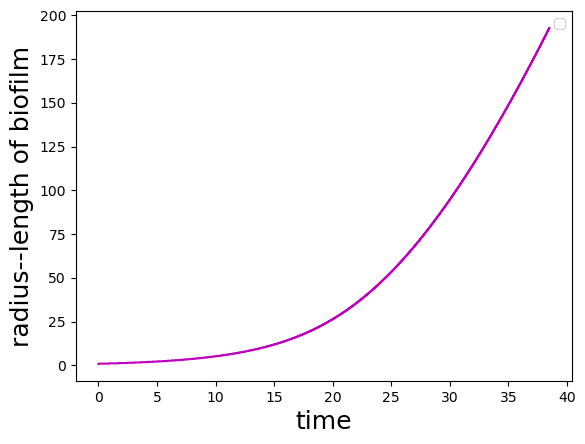

8.159296713379344 13.236303762081263


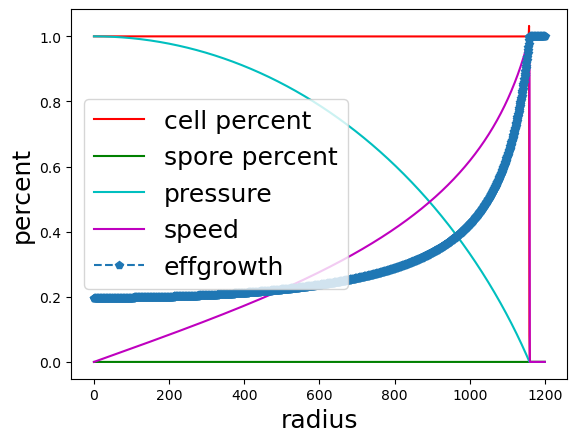

pressure coefficient= 0.02


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


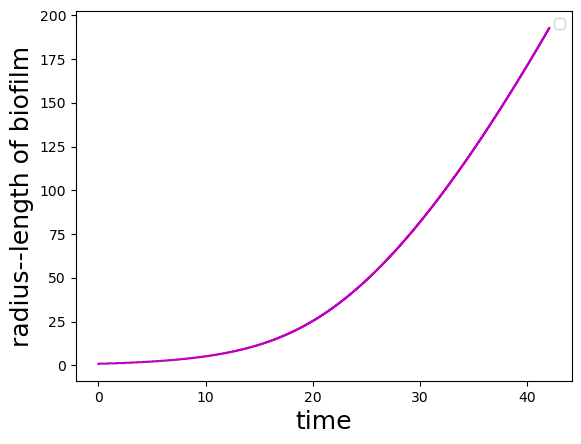

12.078697456580615 10.577381512385804


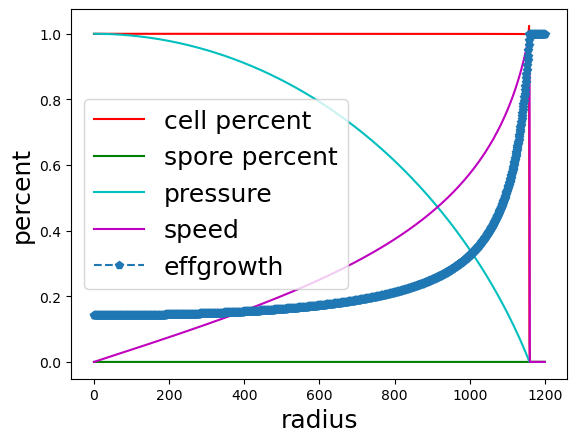

pressure coefficient= 0.04


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


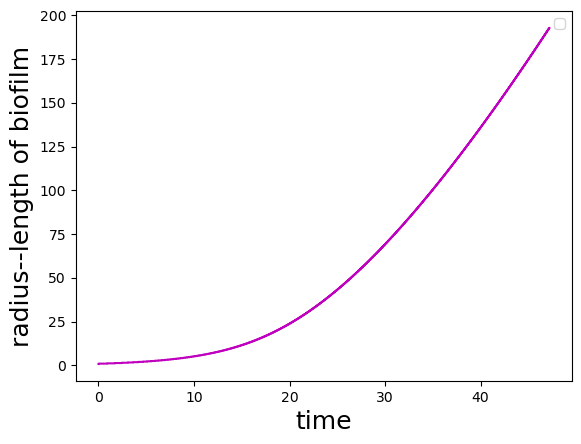

17.650854962332325 8.312763008442346


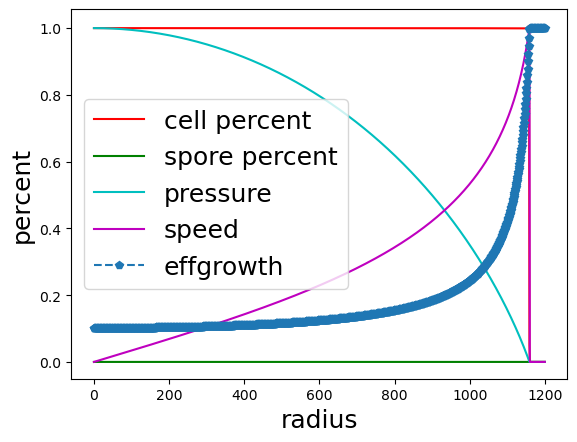

pressure coefficient= 0.08


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


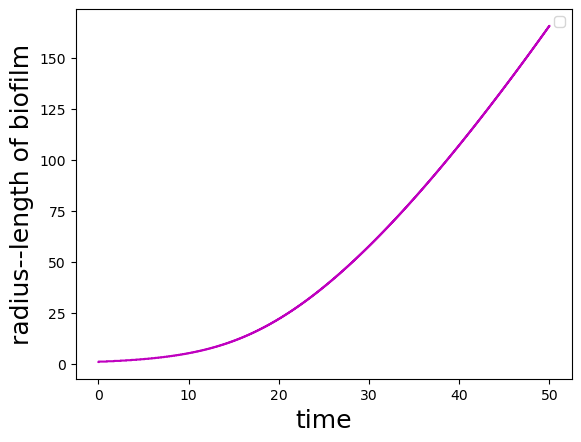

21.729123462288864 6.133506170875297


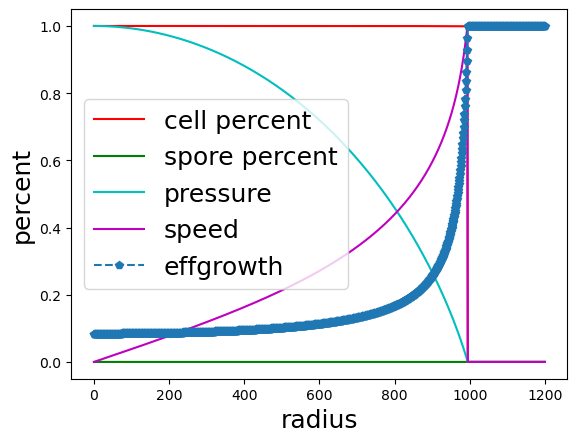

pressure coefficient= 0.16


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


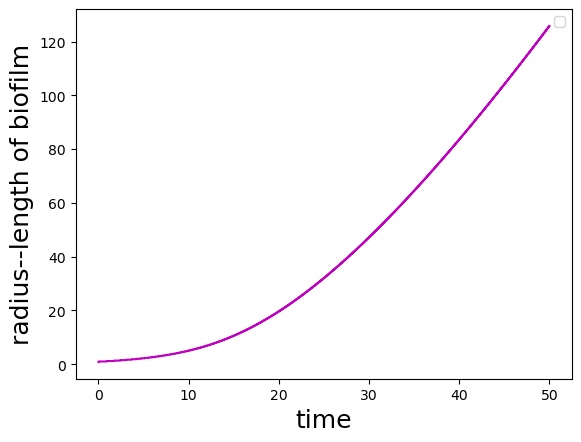

23.472960720614914 4.416791302024059


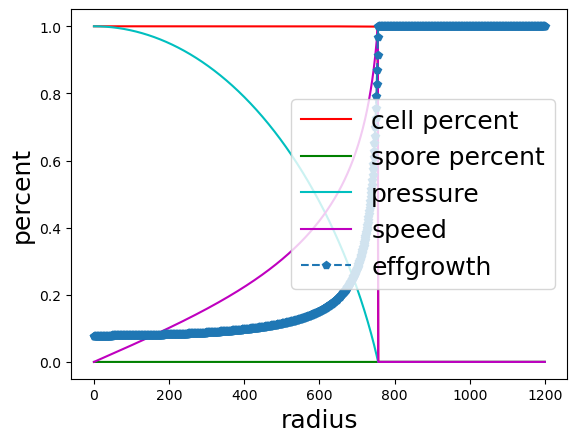

pressure coefficient= 0.32


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


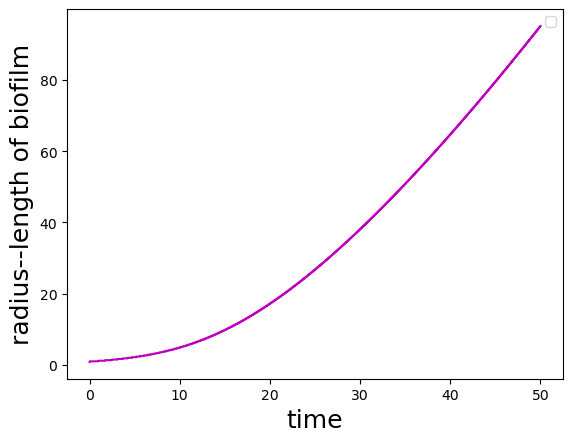

25.214006295000498 3.1641774857283456


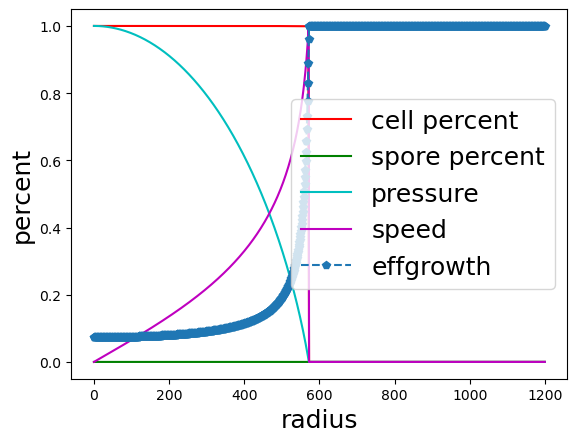

pressure coefficient= 0.64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


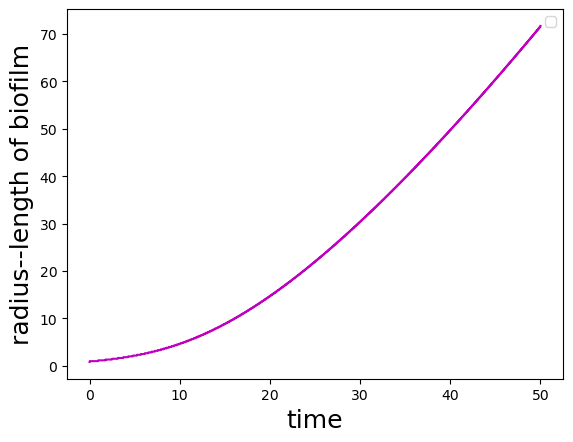

26.9371359470905 2.281089370497264


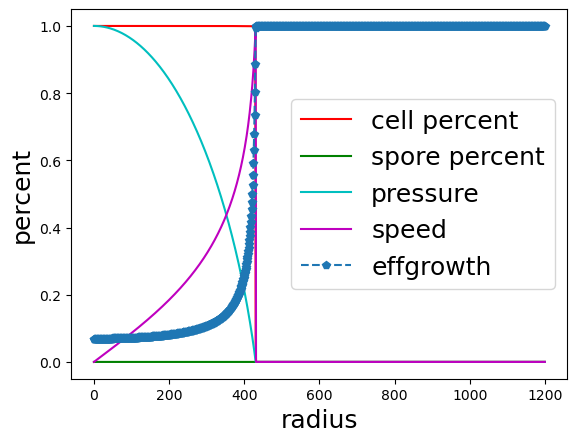

pressure coefficient= 1.28


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


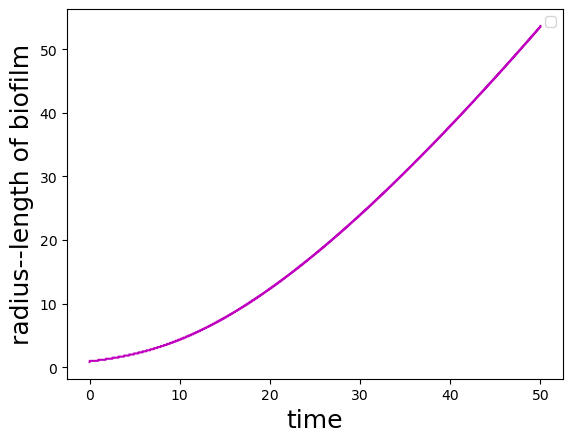

28.624985531238288 1.626441647647534


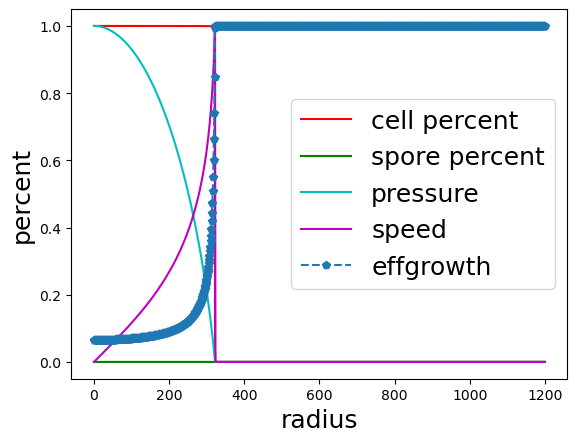

pressure coefficient= 0.01


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


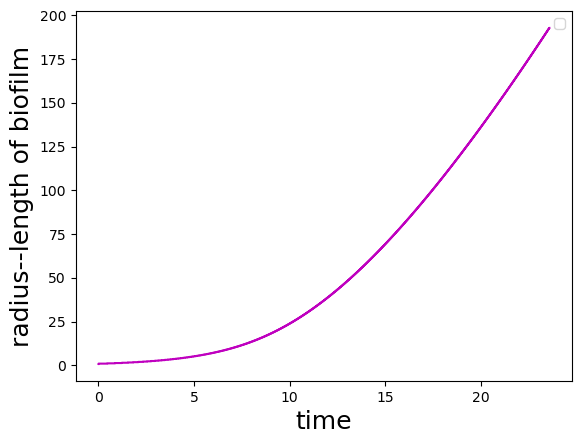

8.824850858947885 16.60851982421925


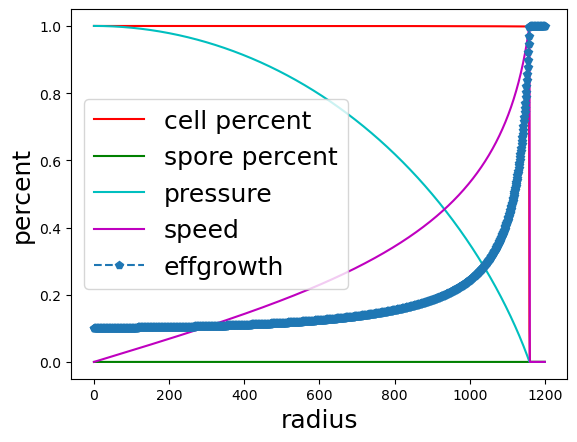

pressure coefficient= 0.02


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


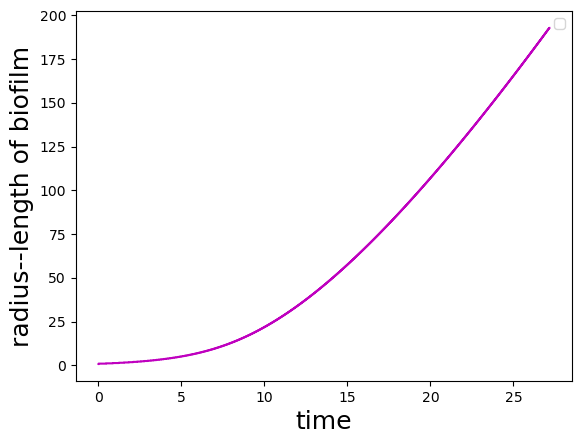

12.776422022271806 12.873594117829722


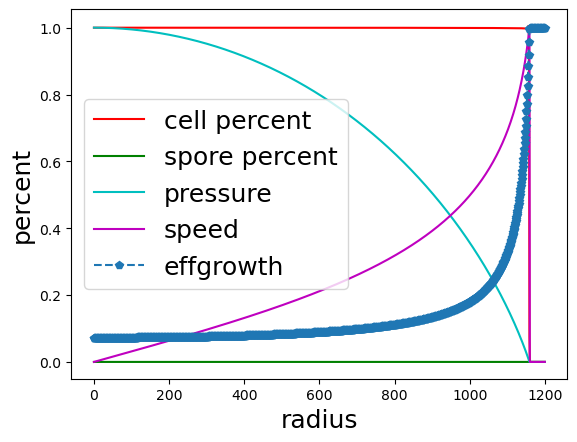

pressure coefficient= 0.04


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


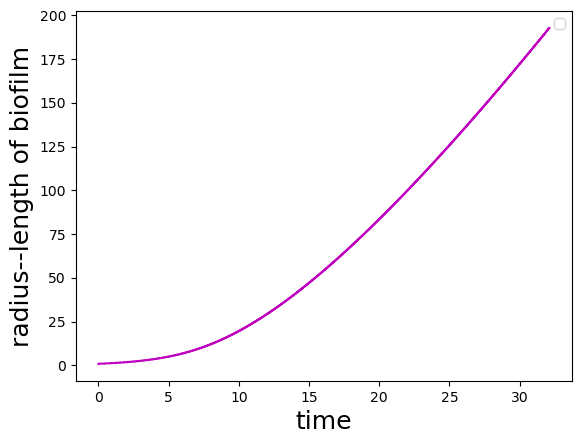

18.37645936857642 9.870115429223143


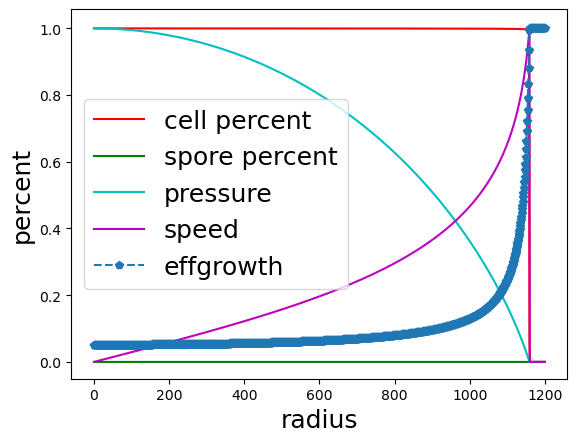

pressure coefficient= 0.08


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


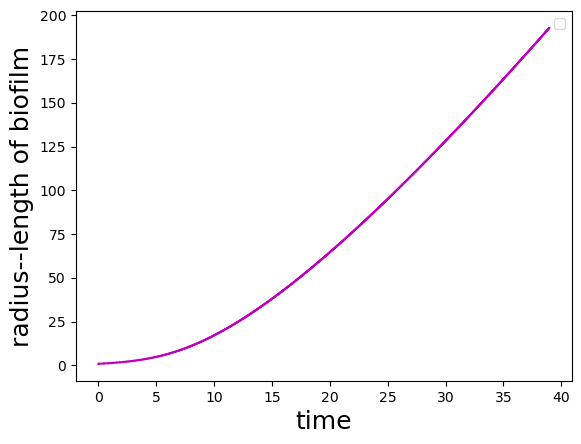

26.301734326962894 7.489411892226641


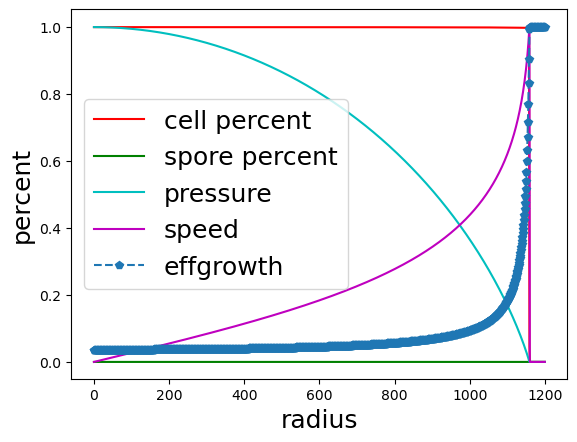

pressure coefficient= 0.16


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


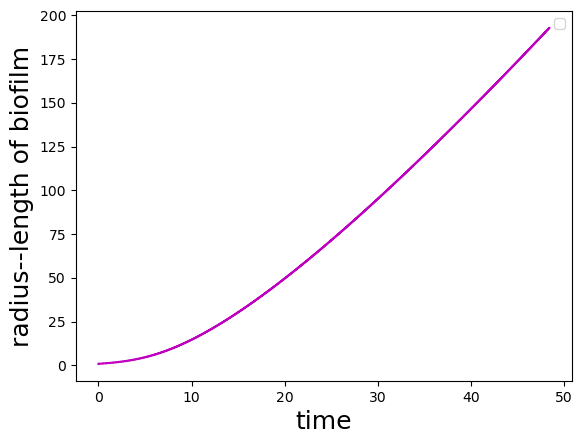

37.51335513542346 5.631139231850527


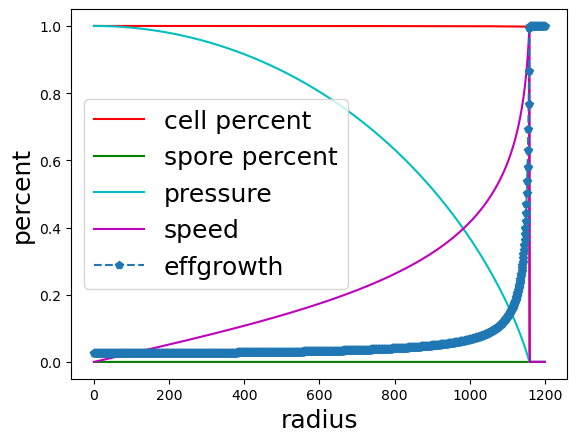

pressure coefficient= 0.32


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


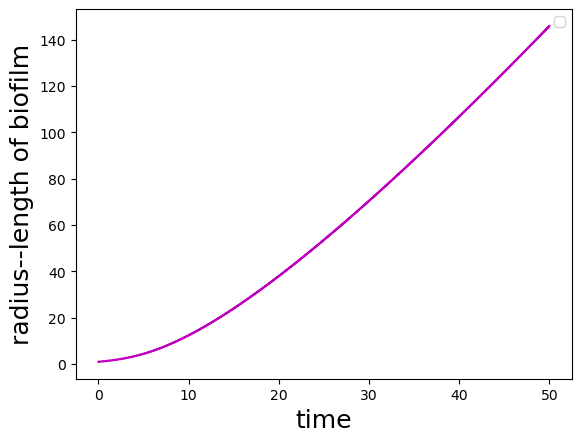

40.20960507697251 3.9755121582020845


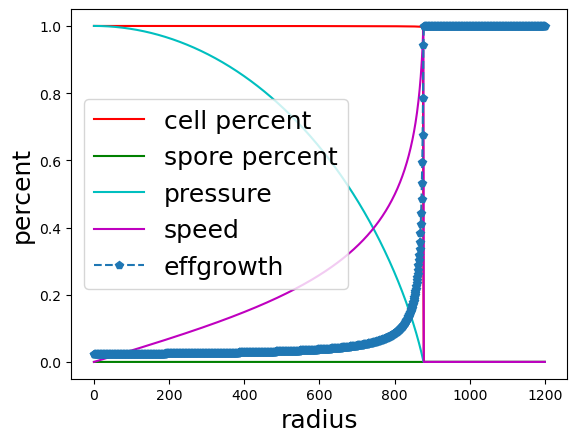

pressure coefficient= 0.64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


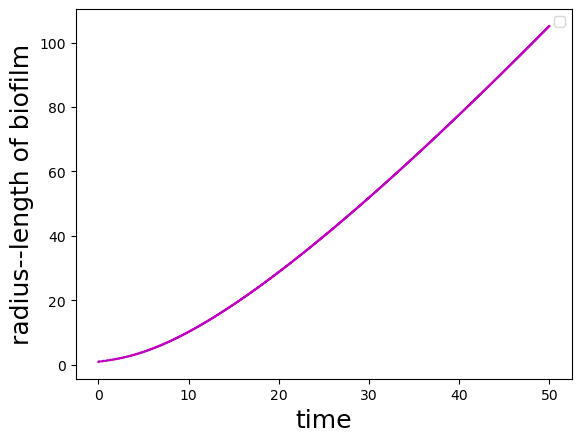

41.01561531031744 2.742386800875148


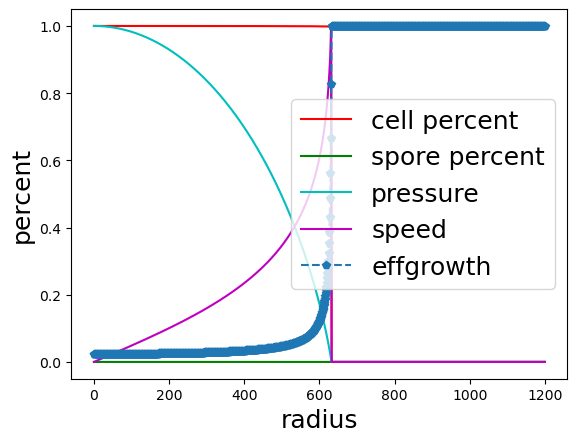

pressure coefficient= 1.28


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


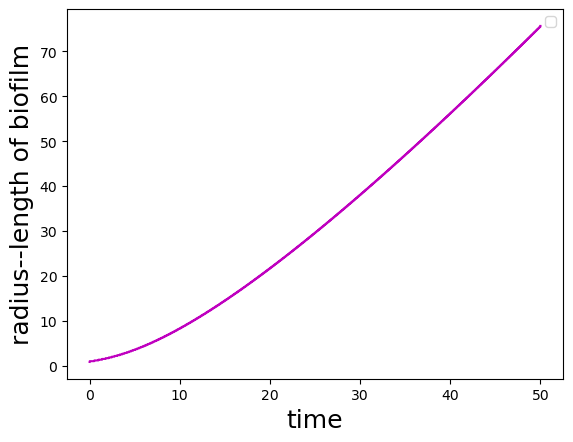

41.71614853876436 1.98311847931837


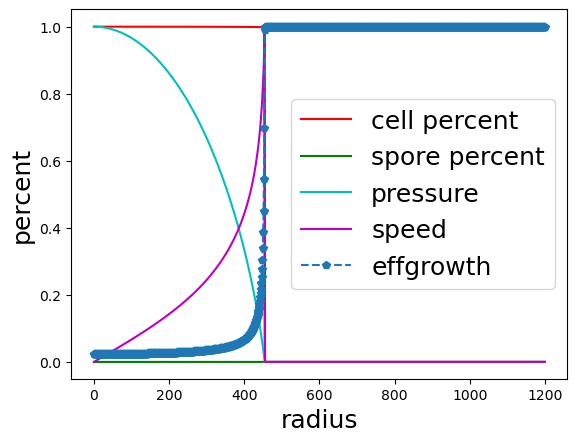

pressure coefficient= 0.01


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


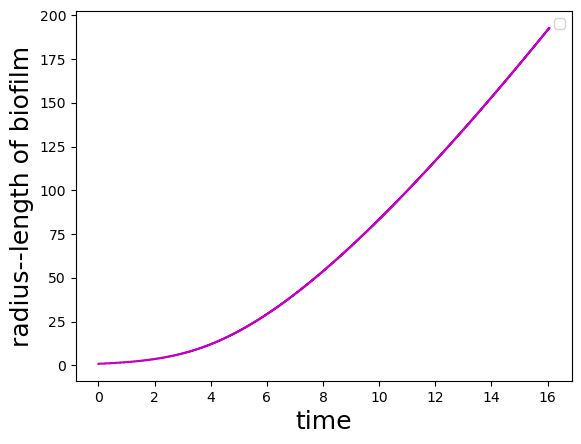

9.18517654343341 19.698080659668


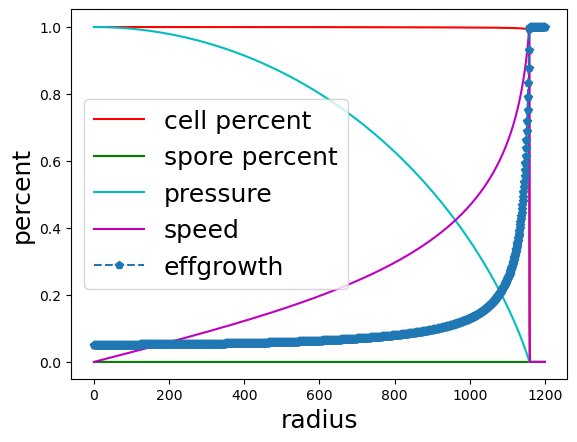

pressure coefficient= 0.02


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


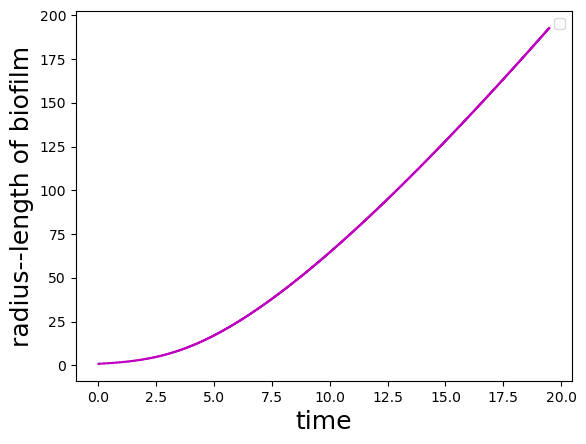

13.148497834076924 14.951894068170937


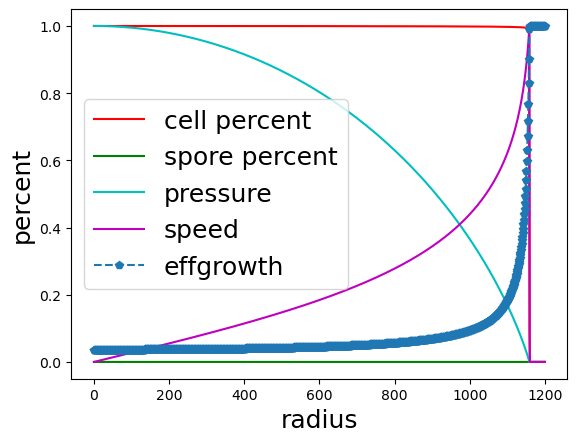

pressure coefficient= 0.04


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


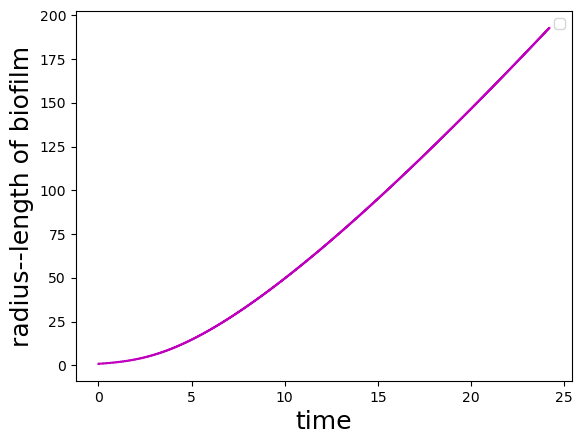

18.756046318237306 11.24941768967428


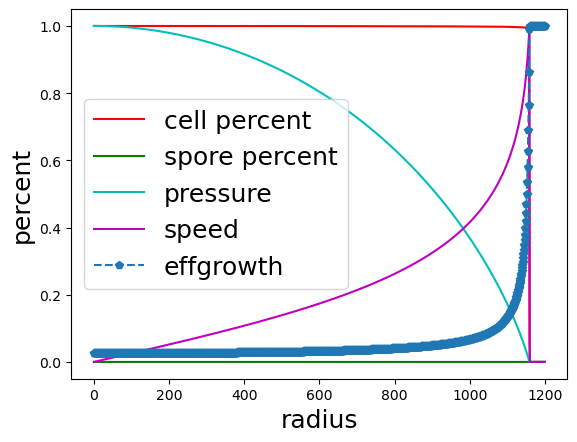

pressure coefficient= 0.08


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


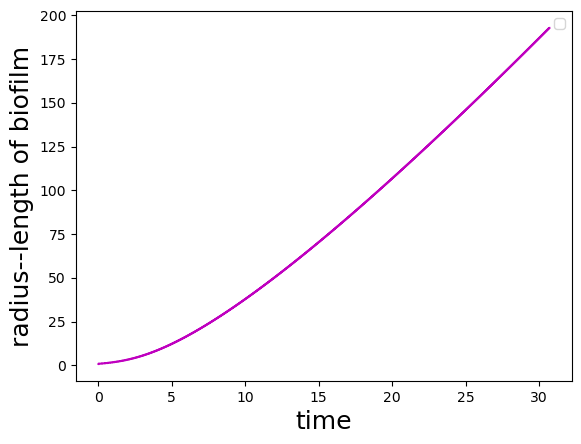

26.689794303056672 8.410463401483918


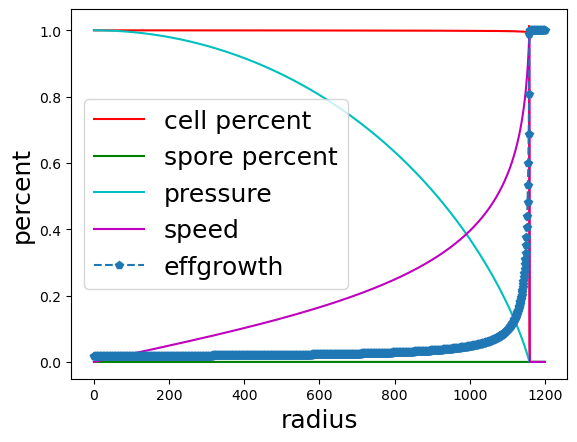

pressure coefficient= 0.16


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


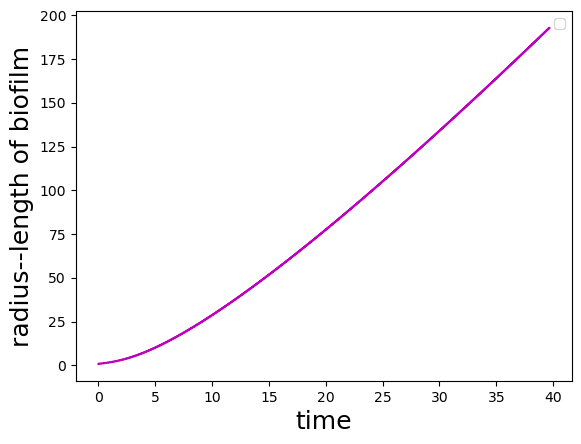

37.908164939667486 6.23198030140767


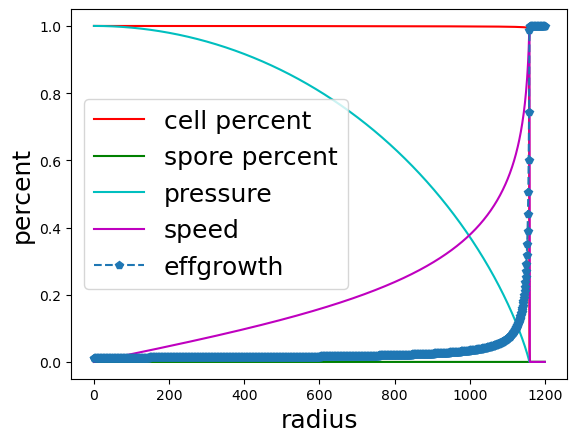

pressure coefficient= 0.32


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


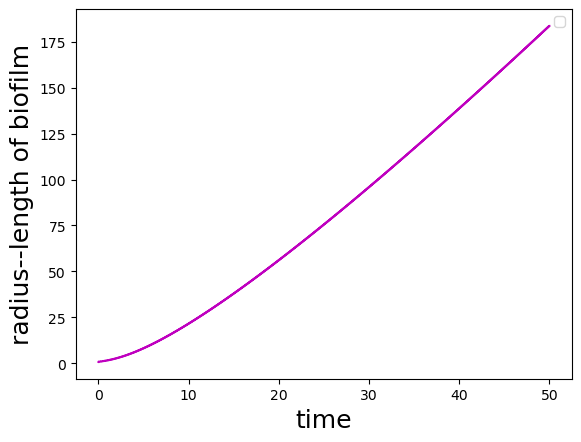

51.15519096733768 4.365237448495422


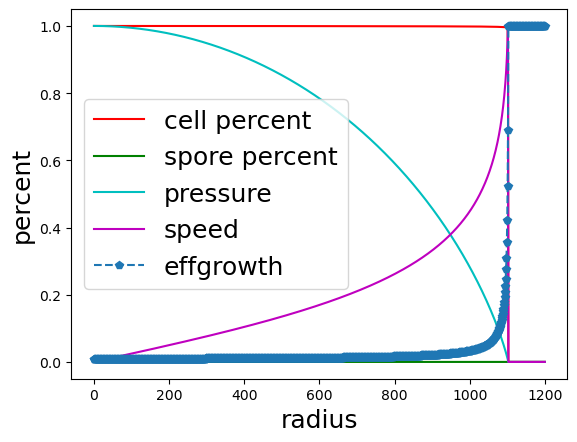

pressure coefficient= 0.64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


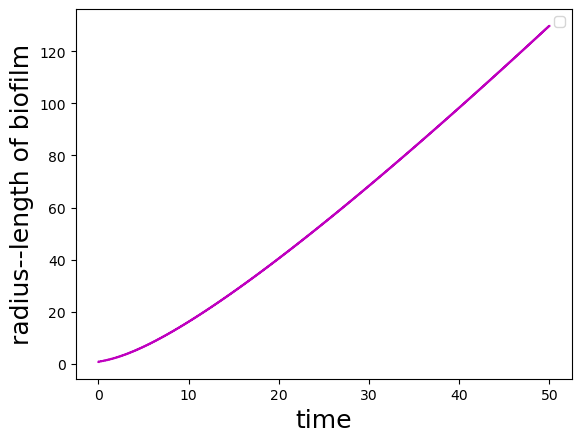

51.150160006749644 3.008555501059773


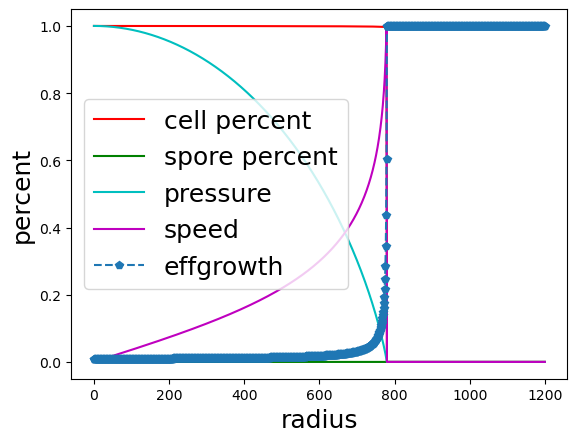

pressure coefficient= 1.28


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


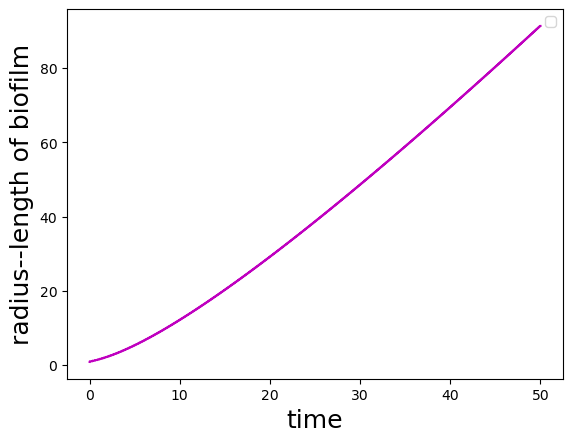

50.992295659331106 2.2183639944067224


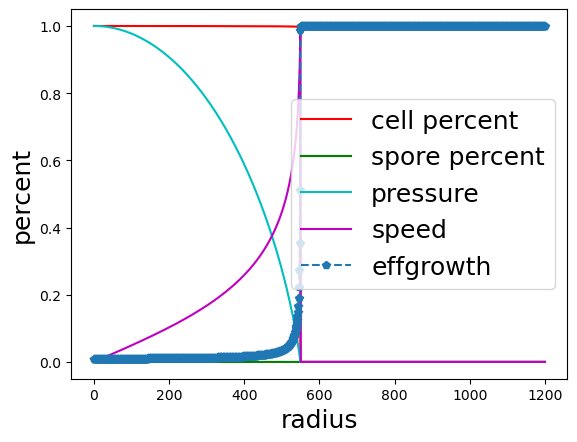

In [3]:
ksiovergp=np.array([0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28])
gval=np.array([0.5,1,2])
pnotval=np.array([2,1,0.5])
vcollect=[]
fin=6
lop=0
u=0
pltr=[]
pltt=[]
pltrfit=[]
plttfit=[]
while lop<len(gval):
    vsingle=[]
    glo=0
    while glo<len(ksiovergp):
        g=gval[lop]
        p=pnotval[lop]
        ks=ksiovergp[glo]*g*p
        phi2,spore2,pressure2,space2,t2,sum2,rsi2,rsit2,speedot2,speedtt2\
            =pressuredegrowth_3d(gnot=g,knot=0,pnott=p,ksii=ks,ca=1,dep=1,\
                                uinput=0,turn=5,boxsize=200*fin,finestep=fin,timeused=50)
        
        space=np.linspace(0,200,200)
        pltr.append(rsit2)
        pltt.append(t2)
        #plt.figure(u)
        #plt.title("2d-pressure,g="+str(g)+",po="+str(p)+",ksi="+str(ks))
        #plt.plot(space1,phi1,"r-",label="amount of cells")
        #plt.plot(space1,spore1,"g-",label="amount of spores")
        #plt.plot(space1,pressure1,"b-",label="pressure")
        #plt.plot(space2,phi2,"r-",label="cell percent")
        #plt.plot(space2,spore2,"g-",label="spore percent")
        #plt.plot(space2,pressure2/max(pressure2),"c-",label="pressure")

        #plt.plot(space1,speed1/max(speed),'m-',label="speed")
        #plt.plot(space1,effgrowth/max(effgrowth),'p--',label='effgrowth')
        #plt.ylabel("amount",fontsize=18)
        #plt.xlabel("radius from center",fontsize=18)
        #plt.xlim(100,150)

        #plt.legend(fontsize=15)
        #plt.show()
        #u=u+1
        #plt.figure(u)
        #plt.title("2-d pressure")
        #u=u+1

        #avarage speed over time
        #t1a=[]
        #speedtt1a=[]
        #i=0
        #trial=np.floor(len(speedtt1)/50)
        #while i<trial:
        #    j=0
        #    sus=0
        #    sut=0
        #    while j<50:
        #        sus=sus+speedtt1[50*i+j]
        #        sut=sut+t1[50*i+j]
        #        j=j+1
        #    speedtt1a.append(sus/50) 
        #    t1a.append(sut/50)
        #    i=i+1
        fitlen=int(len(t2)*(0.66))
        params = curve_fit(fit_func, t2[fitlen:], rsit2[fitlen:])
        [a, b] = params[0]
        #print(a,b)
        #fitr1=[]
        #i=fitlen
        #while i<len(t2):
          #  rfit1=a*t2[i]+b
           # fitr1.append(rfit1)
           # i=i+1

        #plt.plot(t2,rsit2,"b-",label="radius of biofilm")
        #plt.plot(t2[fitlen:],fitr1,"c--",label="linear fit of radius of biofilm over time")
        #pltrfit.append(fitr1)
        #plttfit.append(t2[fitlen:])
        #plt.ylabel("radius",fontsize=18)
        #plt.xlabel("time",fontsize=18)
        #plt.ylim(0,200)
        #plt.xlim(0,50)
        #plt.legend(fontsize=15)
        #plt.show()
        vsingle.append(a)
        glo=glo+1
    lop=lop+1
    vcollect.append(vsingle)

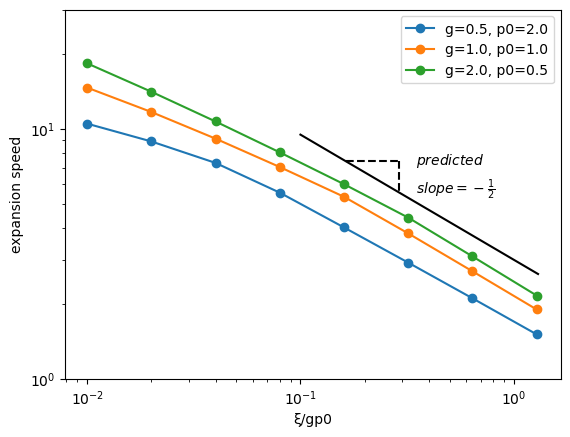

In [4]:
ksiovergp=np.array([0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28])
gval=np.array([0.5,1,2])
pnotval=np.array([2,1,0.5])

plt.figure(1)

plotl=0
while plotl <len(vcollect):
    plt.loglog(ksiovergp,vcollect[plotl],marker='o',label="g="+str(gval[plotl])+", p0="+str(pnotval[plotl]))
    plt.ylim(1,30)
    plt.ylabel("expansion speed")
    plt.xlabel("ξ/gp0")
    plotl=plotl+1
a=np.linspace(0.1,1.3,20)
b=3/a**0.5
cv=a[3]
dv=b[3]
plt.loglog(np.linspace(a[1],a[3],10),np.zeros(10)+b[1],'k--')
plt.loglog(np.zeros(10)+a[3],np.linspace(b[1],b[3],10),'k--')
plt.loglog(a,b,'k-')
plt.text(0.35,7.2,r"$predicted$")
plt.text(0.35,5.5,r"$slope=-\frac{1}{2}$")
plt.legend()

-0.338716900079832 1.12613646892737


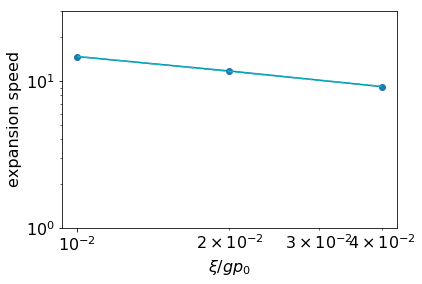

In [8]:
ksiovergp=np.array([0.01,0.02,0.04])#,0.08,0.16,0.32,0.64,1.28])
gval=np.array([0.5,1,2])
pnotval=np.array([2,1,0.5])
def fit_func(x, a, b):
    return a*x + b
plt.figure(1)

plotl=0
while plotl <1:#len(vcollect):
    kogp=[]
    kogp.append(ksiovergp[plotl])
    kogp.append(ksiovergp[plotl])
    kogp.append(ksiovergp[plotl])
    plt.loglog(ksiovergp,vcollect[plotl],marker='o')
    fitlen=0
    params = curve_fit(fit_func, np.log(ksiovergp), np.log(vcollect[0]))
    [a, b] = params[0]
    print(a,b)
    fitr1=[]
    i=fitlen
    while i<len(ksiovergp):
        rfit1=a*np.log(ksiovergp[i])+b
        fitr1.append(rfit1)
        i=i+1

    #plt.plot(ksiovergp,vcollect,"b-",label="simulation speed")
    plt.loglog(ksiovergp[fitlen:],np.exp(fitr1),"c--",label="linear fit")
    
    plt.ylim(1,30)
    plt.ylabel("expansion speed")
    plt.xlabel(r"$ξ/gp_{0}$")
    plotl=plotl+1

In [ ]:
ksiovergp=np.array([0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28])
gval=np.array([0.5,1,2])
pnotval=np.array([2,1,0.5])
vcollect=[]
fin=5
lop=0
u=0
while lop<len(gval):
    vsingle=[]
    glo=0
    while glo<len(ksiovergp):
        g=gval[lop]
        p=pnotval[lop]
        ks=ksiovergp[glo]*g*p
        phi2,spore2,pressure2,space2,t2,sum2,rsi2,rsit2,speedot2,speedtt2\
            =pressuredegrowth_2d(gnot=g,knot=0,pnott=p,ksii=ks,ca=1,dep=1,\
                                uinput=0,turn=5,boxsize=200*fin,finestep=fin,timeused=50)
        
        space=np.linspace(0,200,200)
        plt.figure(u)
        plt.title("2d-pressure,g="+str(g)+",po="+str(p)+",ksi="+str(ks))
        #plt.plot(space1,phi1,"r-",label="amount of cells")
        #plt.plot(space1,spore1,"g-",label="amount of spores")
        #plt.plot(space1,pressure1,"b-",label="pressure")
        plt.plot(space2,phi2,"r-",label="cell percent")
        plt.plot(space2,spore2,"g-",label="spore percent")
        plt.plot(space2,pressure2/max(pressure2),"c-",label="pressure")

        #plt.plot(space1,speed1/max(speed),'m-',label="speed")
        #plt.plot(space1,effgrowth/max(effgrowth),'p--',label='effgrowth')
        plt.ylabel("amount",fontsize=18)
        plt.xlabel("radius from center",fontsize=18)
        #plt.xlim(100,150)

        plt.legend(fontsize=15)
        plt.show()
        u=u+1
        plt.figure(u)
        plt.title("2-d pressure")
        u=u+1

        #avarage speed over time
        #t1a=[]
        #speedtt1a=[]
        #i=0
        #trial=np.floor(len(speedtt1)/50)
        #while i<trial:
        #    j=0
        #    sus=0
        #    sut=0
        #    while j<50:
        #        sus=sus+speedtt1[50*i+j]
        #        sut=sut+t1[50*i+j]
        #        j=j+1
        #    speedtt1a.append(sus/50) 
        #    t1a.append(sut/50)
        #    i=i+1
        fitlen=int(len(t2)/2)
        params = curve_fit(fit_func, t2[fitlen:], rsit2[fitlen:])
        [a, b] = params[0]
        print(a,b)
        fitr1=[]
        i=fitlen
        while i<len(t2):
            rfit1=a*t2[i]+b
            fitr1.append(rfit1)
            i=i+1

        plt.plot(t2,rsit2,"b-",label="radius of biofilm")
        plt.plot(t2[fitlen:],fitr1,"c--",label="linear fit of radius of biofilm over time")
        plt.ylabel("radius",fontsize=18)
        plt.xlabel("time",fontsize=18)
        plt.ylim(0,200)
        plt.xlim(0,50)
        plt.legend(fontsize=15)
        plt.show()
        vsingle.append(a)
        glo=glo+1
    lop=lop+1
    vcollect.append(vsingle)

pressure coefficient= 0.01


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


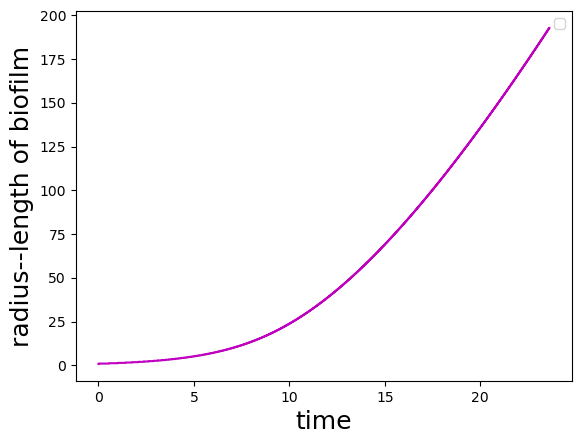

8.827896752498562 16.61214349723552


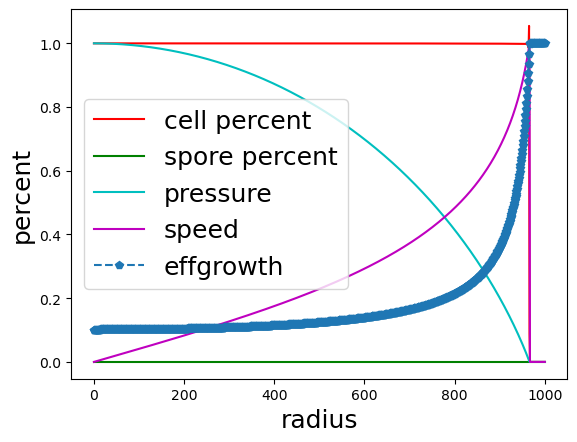

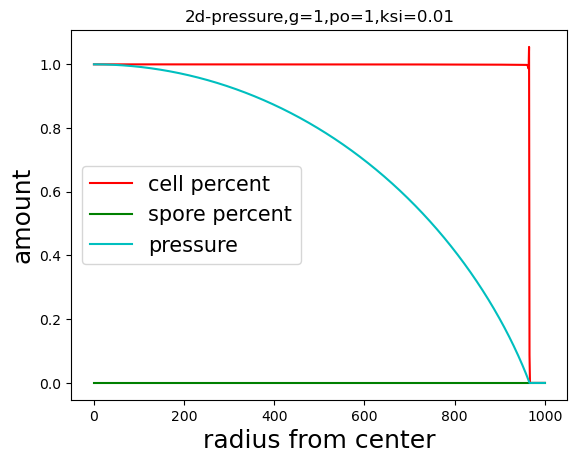

13.332206841347352 -129.03663123271204


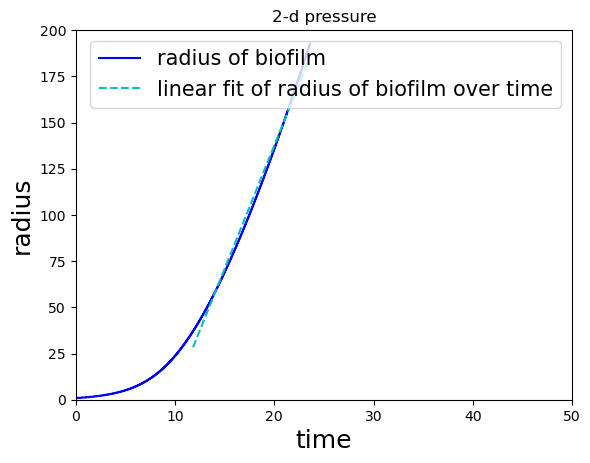

pressure coefficient= 0.02


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


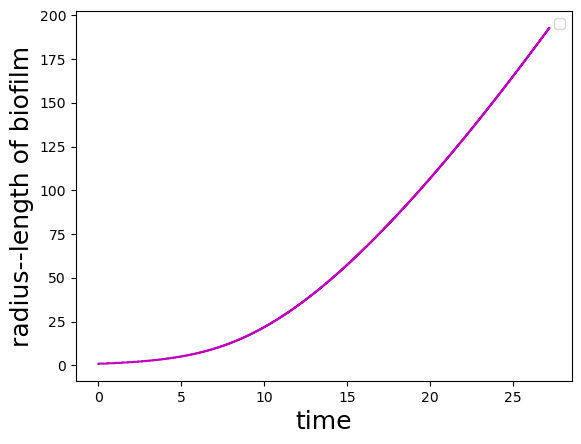

12.777687550656472 12.864354470054387


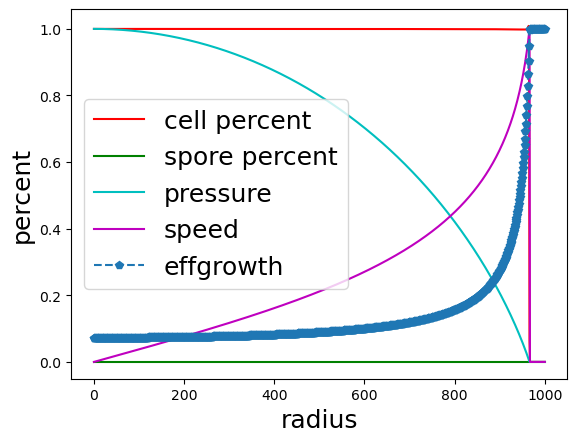

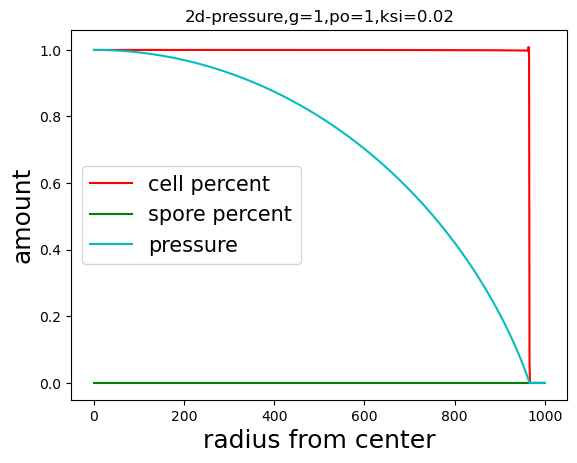

10.90387746436505 -108.51581130687654


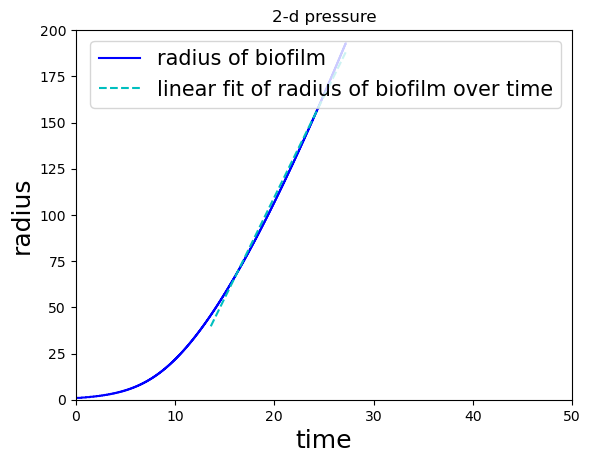

pressure coefficient= 0.04


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


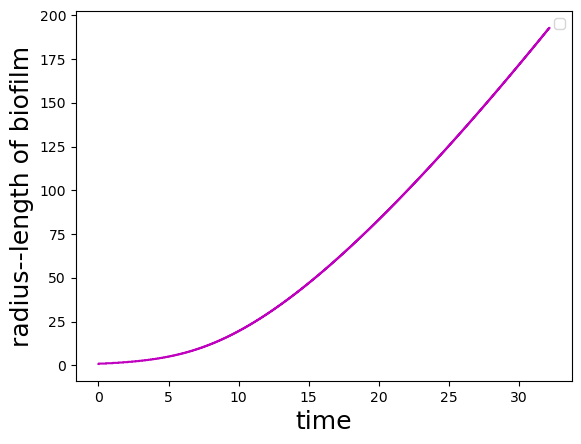

18.37923120777128 9.858338316149736


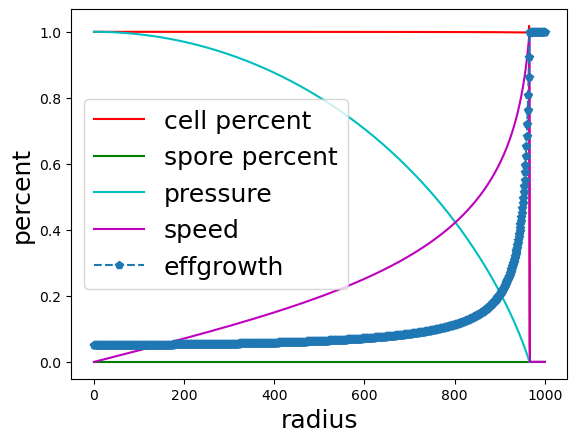

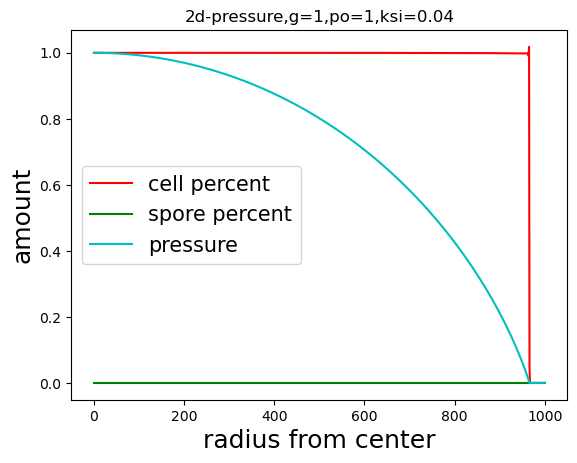

8.66944982194696 -89.45759436323145


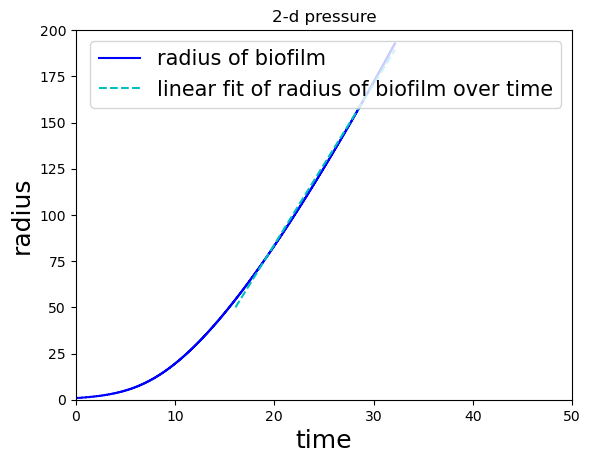

In [3]:
ksiovergp=np.array([0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28])
gval=np.array([0.5,1,2])
pnotval=np.array([2,1,0.5])
vcollect=[]
fin=5
lop=0
u=0
pltr=[]
pltt=[]
pltrfit=[]
plttfit=[]
while lop<1:#len(gval):
    vsingle=[]
    glo=0
    while glo<3:#len(ksiovergp):
        g=1#gval[lop]
        p=1#pnotval[lop]
        ks=ksiovergp[glo]*g*p
        phi2,spore2,pressure2,space2,t2,sum2,rsi2,rsit2,speedot2,speedtt2\
            =pressuredegrowth_3d(gnot=g,knot=0,pnott=p,ksii=ks,ca=1,dep=1,\
                                uinput=0,turn=5,boxsize=200*fin,finestep=fin,timeused=50)
        
        space=np.linspace(0,200,200)
        pltr.append(rsit2)
        pltt.append(t2)
        plt.figure(u)
        plt.title("2d-pressure,g="+str(g)+",po="+str(p)+",ksi="+str(ks))
        #plt.plot(space1,phi1,"r-",label="amount of cells")
        #plt.plot(space1,spore1,"g-",label="amount of spores")
        #plt.plot(space1,pressure1,"b-",label="pressure")
        plt.plot(space2,phi2,"r-",label="cell percent")
        plt.plot(space2,spore2,"g-",label="spore percent")
        plt.plot(space2,pressure2/max(pressure2),"c-",label="pressure")

        #plt.plot(space1,speed1/max(speed),'m-',label="speed")
        #plt.plot(space1,effgrowth/max(effgrowth),'p--',label='effgrowth')
        plt.ylabel("amount",fontsize=18)
        plt.xlabel("radius from center",fontsize=18)
        #plt.xlim(100,150)

        plt.legend(fontsize=15)
        plt.show()
        u=u+1
        plt.figure(u)
        plt.title("2-d pressure")
        u=u+1

        #avarage speed over time
        #t1a=[]
        #speedtt1a=[]
        #i=0
        #trial=np.floor(len(speedtt1)/50)
        #while i<trial:
        #    j=0
        #    sus=0
        #    sut=0
        #    while j<50:
        #        sus=sus+speedtt1[50*i+j]
        #        sut=sut+t1[50*i+j]
        #        j=j+1
        #    speedtt1a.append(sus/50) 
        #    t1a.append(sut/50)
        #    i=i+1
        fitlen=int(len(t2)/2)
        params = curve_fit(fit_func, t2[fitlen:], rsit2[fitlen:])
        [a, b] = params[0]
        print(a,b)
        fitr1=[]
        i=fitlen
        while i<len(t2):
            rfit1=a*t2[i]+b
            fitr1.append(rfit1)
            i=i+1

        plt.plot(t2,rsit2,"b-",label="radius of biofilm")
        plt.plot(t2[fitlen:],fitr1,"c--",label="linear fit of radius of biofilm over time")
        pltrfit.append(fitr1)
        plttfit.append(t2[fitlen:])
        plt.ylabel("radius",fontsize=18)
        plt.xlabel("time",fontsize=18)
        plt.ylim(0,200)
        plt.xlim(0,50)
        plt.legend(fontsize=15)
        plt.show()
        vsingle.append(a)
        glo=glo+1
    lop=lop+1
    vcollect.append(vsingle)

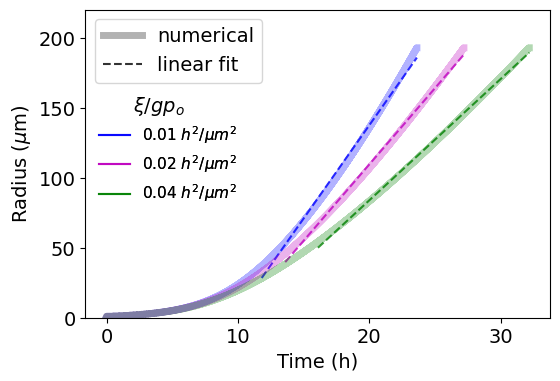

In [4]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams['font.size'] = 14
legend_elements1 = [Line2D([0], [0], color='k', lw=5, alpha=0.3,label='numerical'),
                   Line2D([0], [0], linestyle='--',color='k', alpha=0.8, label='linear fit')]

# Create the figure
fig, ax = plt.subplots(figsize=(6,4))
leng1=ax.legend(handles=legend_elements1, loc='upper left')
i=0
cl=['b','m','g']
while i<len(pltr):
    plt.plot(pltt[i],pltr[i],color=cl[i],linestyle='-',alpha=0.3,linewidth=5)
    plt.plot(plttfit[i],pltrfit[i],color=cl[i],linestyle='--',alpha=0.8)
    i=i+1
#plt.legend()
legend_elements2 = [Line2D([0], [0], color='b', alpha=0.8,label='0.01 $h^{2}/\mu m^{2}$'),
                   Line2D([0], [0], linestyle='-',color='m', alpha=0.8, label='0.02 $h^{2}/\mu m^{2}$'),
                   Line2D([0], [0], linestyle='-',color='g', alpha=0.8, label='0.04 $h^{2}/\mu m^{2}$')]
leng2=ax.legend(handles=legend_elements2,fontsize=11, loc='center left',frameon=False)
#first = []
#second = []
#plt.plot(first, 'b-', second, 'b--')
#plt.legend(['simulation', 'linear fit'], loc='upper left')
ax.add_artist(leng1)
ax.add_artist(leng2)
#plt.title("Pressure Limited Growth-3D")
plt.xlabel(r"Time (h)")
plt.ylabel(r"Radius ($\mu$m)")
plt.ylim(0,220)

#plt.xlim(0,21)
plt.text(2,147,r"$ξ/gp_{o}$",fontsize=14)
#plt.text(20,200,"ξ/gpo=0.02",fontsize=10)
#plt.text(25,200,"ξ/gpo=0.04",fontsize=10)
plt.savefig("3d_pressure_radius_over_time_profile.png",bbox_inches = 'tight',dpi=600)
